In [21]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import timm
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import confusion_matrix, classification_report

import time
from tqdm import tqdm
from IPython.display import clear_output

In [ ]:
# 2. Device Configuration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# 3. Dataset Paths

train_dir = "../dataset/RiceLeafsDisease/train"
val_dir = "../dataset/RiceLeafsDisease/validation"

In [ ]:
# 4. Data Transformations

# Training Transform (with augmentation)

train_transform = transforms.Compose([
    
    transforms.Resize((224,224)),
    
    transforms.RandomHorizontalFlip(),
    
    transforms.RandomRotation(20),
    
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    
    transforms.ToTensor(),
    
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
# 5. Validation Transform (no augmentation)

val_transform = transforms.Compose([
    
    transforms.Resize((224,224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
# 6. Load Dataset

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=val_transform
)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot']


In [ ]:
# 7. Optimized DataLoaders
batch_size = 8

# Optimize DataLoader settings
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,  # Use multiple CPU cores
    pin_memory=True,  # Faster GPU transfer
    persistent_workers=True,  # Keep workers alive between epochs
    prefetch_factor=2  # Pre-load batches
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print(f"Batch size: {batch_size}, Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Batch size: 8, Train batches: 263, Val batches: 66


In [ ]:
# 8. Load EfficientNet Model with Optimizations

model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=len(class_names)
)

# FREEZE the backbone (ONLY train the classifier)
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the classifier
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")
print("Model loaded and optimized for MX250!")

Trainable params: 7,686 / 4,015,234 (0.2%)
Model loaded and optimized for MX250!


In [ ]:
# 9. Optimizer - Only train classifier parameters
optimizer = optim.Adam(
    model.classifier.parameters(),  # Only train classifier
    lr=0.001  # Higher learning rate for classifier-only training
)

criterion = nn.CrossEntropyLoss()

# Add learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# Add mixed precision training
scaler = torch.amp.GradScaler('cuda')

In [ ]:
# 10. Optimized Training Function with Mixed Precision
from tqdm import tqdm
import time

def train_epoch(model, loader, optimizer, criterion, scaler, epoch_num):
    model.train()
    total_loss = 0
    correct = 0
    batch_times = []
    
    progress_bar = tqdm(loader, desc=f'Epoch {epoch_num} Training')
    for batch_idx, (images, labels) in enumerate(progress_bar):
        batch_start = time.time()
        
        # Move data to GPU (non_blocking for async transfer)
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        # Backward pass with scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Statistics
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        
        # Update progress bar
        batch_time = time.time() - batch_start
        batch_times.append(batch_time)
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'avg_batch_time': f'{sum(batch_times[-10:])/min(10, len(batch_times)):.2f}s'
        })
        
        # Clear cache occasionally
        if batch_idx % 50 == 0:
            torch.cuda.empty_cache()
    
    accuracy = correct / len(loader.dataset)
    avg_time = sum(batch_times) / len(batch_times)
    print(f"Avg batch time: {avg_time:.2f}s, Total batches: {len(batch_times)}")
    
    return total_loss/len(loader), accuracy

In [ ]:
# 11. Optimized Validation Function
def validate_epoch(model, loader, criterion, epoch_num):
    model.eval()
    total_loss = 0
    correct = 0
    
    with torch.no_grad():
        progress_bar = tqdm(loader, desc=f'Epoch {epoch_num} Validation')
        for images, labels in progress_bar:
            # Move data to GPU
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            # Forward pass (no mixed precision needed for validation)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    accuracy = correct / len(loader.dataset)
    return total_loss/len(loader), accuracy

In [ ]:
# 12. Optimized Training Loop with Timing
epochs = 20
train_losses = []
val_losses = []
train_acc = []
val_acc = []

total_start_time = time.time()

for epoch in range(epochs):
    epoch_start = time.time()
    
    # Train
    train_loss, train_accuracy = train_epoch(model, train_loader, optimizer, criterion, scaler, epoch+1)
    
    # Validate
    val_loss, val_accuracy = validate_epoch(model, val_loader, criterion, epoch+1)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_acc.append(train_accuracy)
    val_acc.append(val_accuracy)
    
    epoch_time = time.time() - epoch_start
    total_time_so_far = time.time() - total_start_time
    
    # Clear output for clean display
    from IPython.display import clear_output
    clear_output(wait=True)
    
    print("="*60)
    print(f"Epoch {epoch+1}/{epochs} - Time: {epoch_time/60:.2f} minutes")
    print("="*60)
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.4f}")
    print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")
    print(f"Total time elapsed: {total_time_so_far/60:.2f} minutes")
    print("="*60)
    
    # Early stopping if needed
    if val_accuracy > 0.95:
        print("Reached 95% validation accuracy! Stopping early.")
        break

print(f"\n✅ Training completed in {total_time_so_far/60:.2f} minutes!")

Epoch 20/20 - Time: 2.47 minutes
Train Loss: 0.5162 | Train Accuracy: 0.8152
Val Loss: 0.6203 | Val Accuracy: 0.7727
Current LR: 0.001000
Total time elapsed: 49.29 minutes

✅ Training completed in 49.29 minutes!


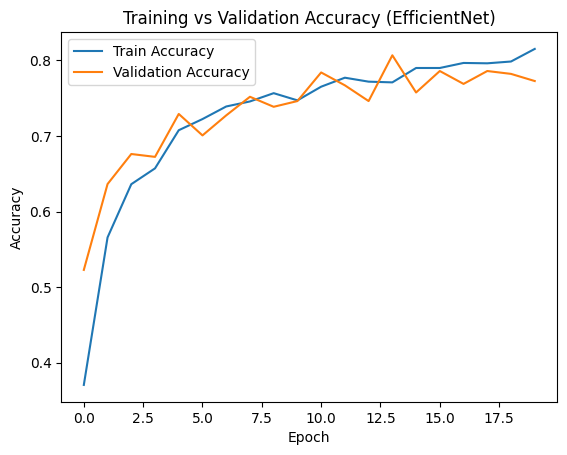

In [ ]:
# 13. Accuracy Graph

plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.title("Training vs Validation Accuracy (EfficientNet)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

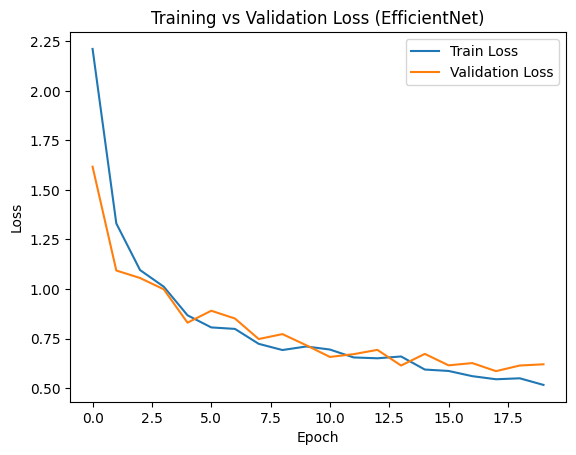

In [ ]:
# 14. Loss Graph

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Training vs Validation Loss (EfficientNet)")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
# 15. Model Evaluation

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [ ]:
# 16. Classification Report

print(classification_report(all_labels, all_preds, target_names=class_names))

                       precision    recall  f1-score   support

bacterial_leaf_blight       0.88      0.91      0.89        88
           brown_spot       0.72      0.66      0.69        88
              healthy       0.83      0.85      0.84        88
           leaf_blast       0.59      0.69      0.64        88
           leaf_scald       0.79      0.94      0.86        88
    narrow_brown_spot       0.86      0.58      0.69        88

             accuracy                           0.77       528
            macro avg       0.78      0.77      0.77       528
         weighted avg       0.78      0.77      0.77       528



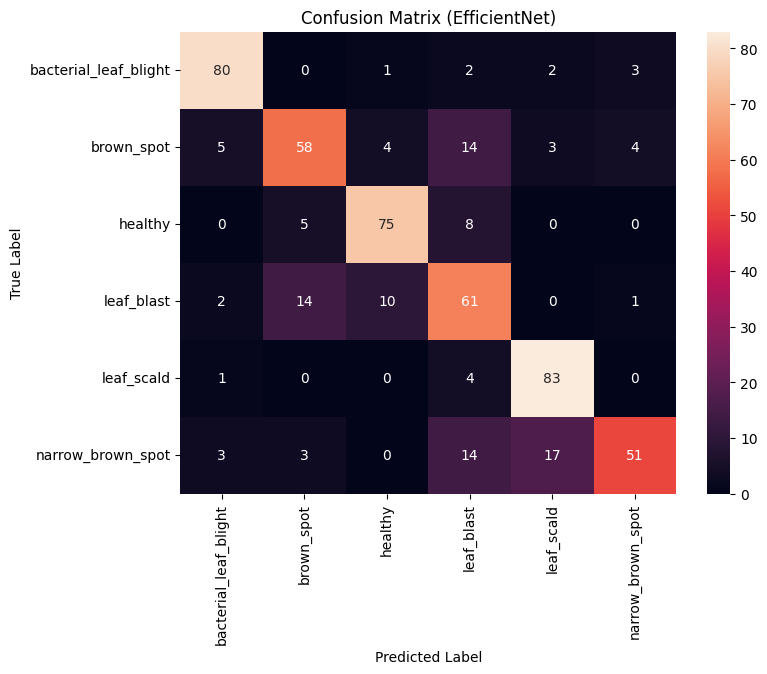

In [ ]:
# 17. Confusion Matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix (EfficientNet)")

plt.show()

In [ ]:
# 18. Save Model

torch.save(
    model.state_dict(),
    "efficientnet_paddy_model.pth"
)

print("Model saved successfully!")

# Save EfficientNet results
efficientnet_results = {
    'train_acc': train_acc,  # Use your actual variable names
    'val_acc': val_acc,
    'train_loss': train_losses,
    'val_loss': val_losses,
    'model_name': 'EfficientNet-B0'
}

with open('efficientnet_results.pkl', 'wb') as f:
    pickle.dump(efficientnet_results, f)
    
print("EfficientNet results saved!")

Model saved successfully!
EfficientNet results saved!


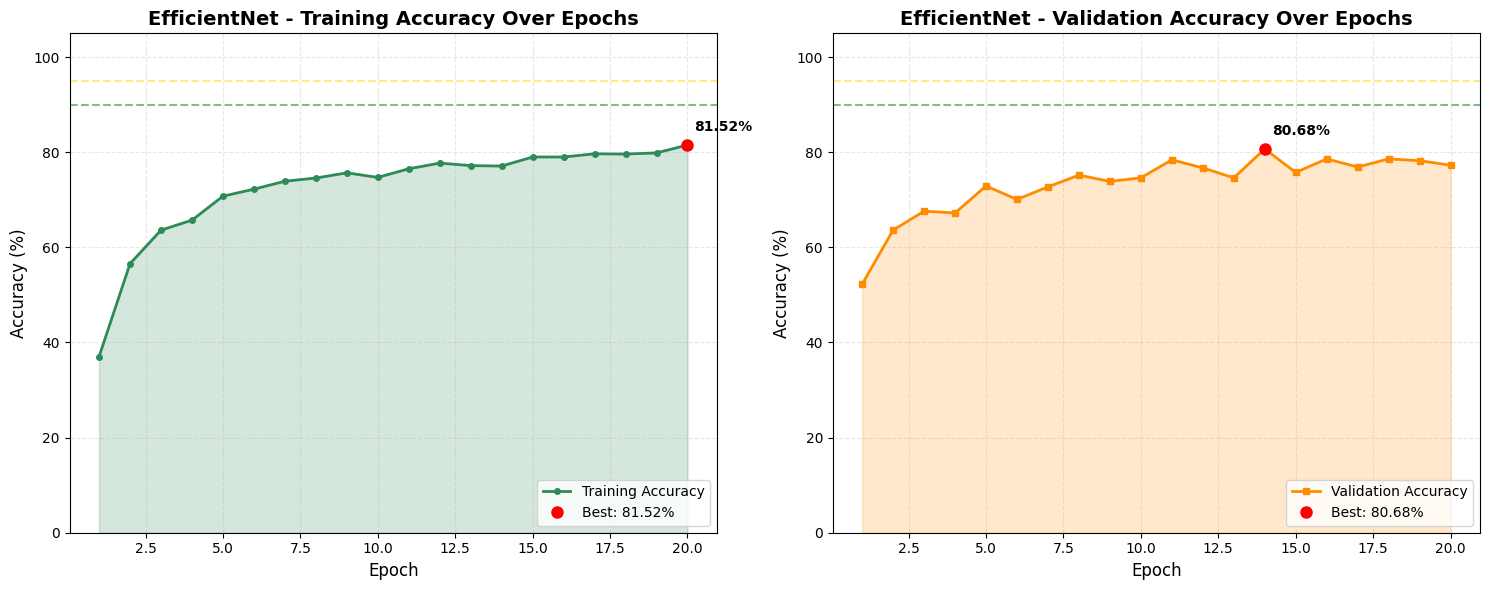


📊 EFFICIENTNET ACCURACY STATISTICS

📈 TRAINING ACCURACY:
   • Initial (Epoch 1): 37.05%
   • Final (Epoch 20): 81.52%
   • Best: 81.52% (Epoch 20)
   • Average: 72.60%
   • Improvement: 44.48%

📉 VALIDATION ACCURACY:
   • Initial (Epoch 1): 52.27%
   • Final (Epoch 20): 77.27%
   • Best: 80.68% (Epoch 14)
   • Average: 73.30%
   • Improvement: 25.00%

🔍 OVERFITTING CHECK:
   📊 Mild overfitting (Gap: 4.25%)
   💡 Consider early stopping


In [ ]:
# 19. Plot Training vs Validation Accuracy Separately (EfficientNet)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Colors (different shades for EfficientNet)
train_color = '#2E8B57'  # Sea Green
val_color = '#FF8C00'    # Dark Orange

# ===== LEFT PLOT: Training Accuracy Only =====
axes[0].plot(range(1, len(train_acc)+1), 
             [acc*100 for acc in train_acc], 
             marker='o', markersize=4, linewidth=2, color=train_color, label='Training Accuracy')
axes[0].fill_between(range(1, len(train_acc)+1), 
                      [acc*100 for acc in train_acc], 
                      alpha=0.2, color=train_color)

# Add best training accuracy annotation
best_train_epoch = np.argmax(train_acc) + 1
best_train_acc = max(train_acc) * 100
axes[0].plot(best_train_epoch, best_train_acc, 'ro', markersize=8, label=f'Best: {best_train_acc:.2f}%')
axes[0].annotate(f'{best_train_acc:.2f}%', 
                 xy=(best_train_epoch, best_train_acc), 
                 xytext=(5, 10), textcoords='offset points', fontsize=10, fontweight='bold')

axes[0].set_title('EfficientNet - Training Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_ylim([0, 105])
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].legend(loc='lower right')
axes[0].axhline(y=90, color='green', linestyle='--', alpha=0.5, label='90% threshold')
axes[0].axhline(y=95, color='gold', linestyle='--', alpha=0.5, label='95% threshold')

# ===== RIGHT PLOT: Validation Accuracy Only =====
axes[1].plot(range(1, len(val_acc)+1), 
             [acc*100 for acc in val_acc], 
             marker='s', markersize=4, linewidth=2, color=val_color, label='Validation Accuracy')
axes[1].fill_between(range(1, len(val_acc)+1), 
                      [acc*100 for acc in val_acc], 
                      alpha=0.2, color=val_color)

# Add best validation accuracy annotation
best_val_epoch = np.argmax(val_acc) + 1
best_val_acc = max(val_acc) * 100
axes[1].plot(best_val_epoch, best_val_acc, 'ro', markersize=8, label=f'Best: {best_val_acc:.2f}%')
axes[1].annotate(f'{best_val_acc:.2f}%', 
                 xy=(best_val_epoch, best_val_acc), 
                 xytext=(5, 10), textcoords='offset points', fontsize=10, fontweight='bold')

axes[1].set_title('EfficientNet - Validation Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_ylim([0, 105])
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].legend(loc='lower right')
axes[1].axhline(y=90, color='green', linestyle='--', alpha=0.5, label='90% threshold')
axes[1].axhline(y=95, color='gold', linestyle='--', alpha=0.5, label='95% threshold')

plt.tight_layout()
plt.show()

# ===== PRINT DETAILED STATISTICS =====
print("\n" + "="*60)
print("📊 EFFICIENTNET ACCURACY STATISTICS")
print("="*60)

print(f"\n📈 TRAINING ACCURACY:")
print(f"   • Initial (Epoch 1): {train_acc[0]*100:.2f}%")
print(f"   • Final (Epoch {len(train_acc)}): {train_acc[-1]*100:.2f}%")
print(f"   • Best: {best_train_acc:.2f}% (Epoch {best_train_epoch})")
print(f"   • Average: {np.mean(train_acc)*100:.2f}%")
print(f"   • Improvement: {train_acc[-1]*100 - train_acc[0]*100:.2f}%")

print(f"\n📉 VALIDATION ACCURACY:")
print(f"   • Initial (Epoch 1): {val_acc[0]*100:.2f}%")
print(f"   • Final (Epoch {len(val_acc)}): {val_acc[-1]*100:.2f}%")
print(f"   • Best: {best_val_acc:.2f}% (Epoch {best_val_epoch})")
print(f"   • Average: {np.mean(val_acc)*100:.2f}%")
print(f"   • Improvement: {val_acc[-1]*100 - val_acc[0]*100:.2f}%")

# Check for overfitting
print(f"\n🔍 OVERFITTING CHECK:")
train_final = train_acc[-1]*100
val_final = val_acc[-1]*100
gap = train_final - val_final

if gap > 5:
    print(f"   ⚠️  Possible overfitting! (Gap: {gap:.2f}%)")
    print(f"   💡 Try adding dropout or increasing data augmentation")
elif gap > 2:
    print(f"   📊 Mild overfitting (Gap: {gap:.2f}%)")
    print(f"   💡 Consider early stopping")
else:
    print(f"   ✅ Good generalization! (Gap: {gap:.2f}%)")
    print(f"   💡 EfficientNet is learning well")

print("="*60)